# Analyzing Factors Influencing the Popularity of Computer Monitors in Online Markets

In [1]:
import sys
import config
import load
import process
import analysis
import visualize
import os
from IPython.display import Image, display

os.makedirs(config.DATA_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)

## Step 1: Load and Clean Product Data

In [2]:
df = load.get_kaggle_data(config.KAGGLE_DATASET_SLUG)
print(f"Loaded dataset with {len(df)} records")
df.head()

Successfully loaded dataset from D:\SSI\DSCI510\finalproject_hanrui\data\extracted_product_info_amazon.csv.
Loaded dataset with 947 records


,Title,Brand,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,"acer SB240Y G0bi 23.8"" IPS Full HD Ultra-Slim ...",acer,23.8 Inches,FHD 1080p,16:9,4.4,94.99
1,"acer Nitro 31.5"" FHD 1920 x 1080 1500R Curved ...",acer,31.5 Inches,FHD 1080p,16:9,4.6,259.99
2,"Acer SB272 EBI 27"" Full HD (1920 x 1080) IPS Z...",acer,27 Inches,FHD 1080p,16:9,4.5,99.99
3,Sceptre 30-inch Curved Gaming Monitor 21:9 256...,Sceptre,30 Inches,FHD 1080p Ultra Wide,21:9,4.5,199.97
4,"SAMSUNG 32"" UJ59 Series 4K UHD (3840x2160) Com...",SAMSUNG,31.5 Inches,4K UHD 2160p,16:9,4.3,279.99


In [3]:
df_clean = process.clean_data(df)
df_clean.to_csv(config.CLEANED_CSV, index=False)
print(f"Cleaned data saved to {config.CLEANED_CSV}: {len(df_clean)}")
df_clean.head()

Data cleaned: 269 monitor products identified.
Cleaned data saved to D:\SSI\DSCI510\finalproject_hanrui\results\cleaned_products.csv: 269


,Title,Brand,Screen Size,Resolution,Aspect Ratio,Rating,Price
0,"acer SB240Y G0bi 23.8"" IPS Full HD Ultra-Slim ...",acer,24.0,1080p,16:9,4.4,94.99
1,"acer Nitro 31.5"" FHD 1920 x 1080 1500R Curved ...",acer,32.0,1080p,16:9,4.6,259.99
2,"Acer SB272 EBI 27"" Full HD (1920 x 1080) IPS Z...",acer,27.0,1080p,16:9,4.5,99.99
3,Sceptre 30-inch Curved Gaming Monitor 21:9 256...,Sceptre,30.0,1080p,21:9,4.5,199.97
4,"SAMSUNG 32"" UJ59 Series 4K UHD (3840x2160) Com...",SAMSUNG,32.0,2160p,16:9,4.3,279.99


## Step 2: Fetch Google Trends Data
#### The entire fetching process takes about six minutes.

Fetching trends for batch 1/7: ['acer monitor', 'SAMSUNG monitor', 'LG monitor', 'ASUS monitor', 'Dell monitor']
Fetching trends for batch 2/7: ['ASUS monitor', 'Dell monitor', 'ViewSonic monitor', 'MSI monitor', 'Lenovo monitor']
Fetching trends for batch 3/7: ['MSI monitor', 'Lenovo monitor', 'HP monitor', 'Sceptre monitor', 'GIGABYTE monitor']
Fetching trends for batch 4/7: ['Sceptre monitor', 'GIGABYTE monitor', 'KOORUI monitor', 'AOC monitor', 'BenQ monitor']
Fetching trends for batch 5/7: ['AOC monitor', 'BenQ monitor', 'LESOWN monitor', 'LILLIPUT monitor', 'domyfan monitor']
Fetching trends for batch 6/7: ['LILLIPUT monitor', 'domyfan monitor', 'InnoView monitor', 'Planar monitor', 'Elo monitor']
Fetching trends for batch 7/7: ['Planar monitor', 'Elo monitor']
429 rate limited. Waiting 68 seconds before retry...
429 rate limited. Waiting 99 seconds before retry...
[output] saved -> D:\SSI\DSCI510\finalproject_hanrui\results\trends_combined.png


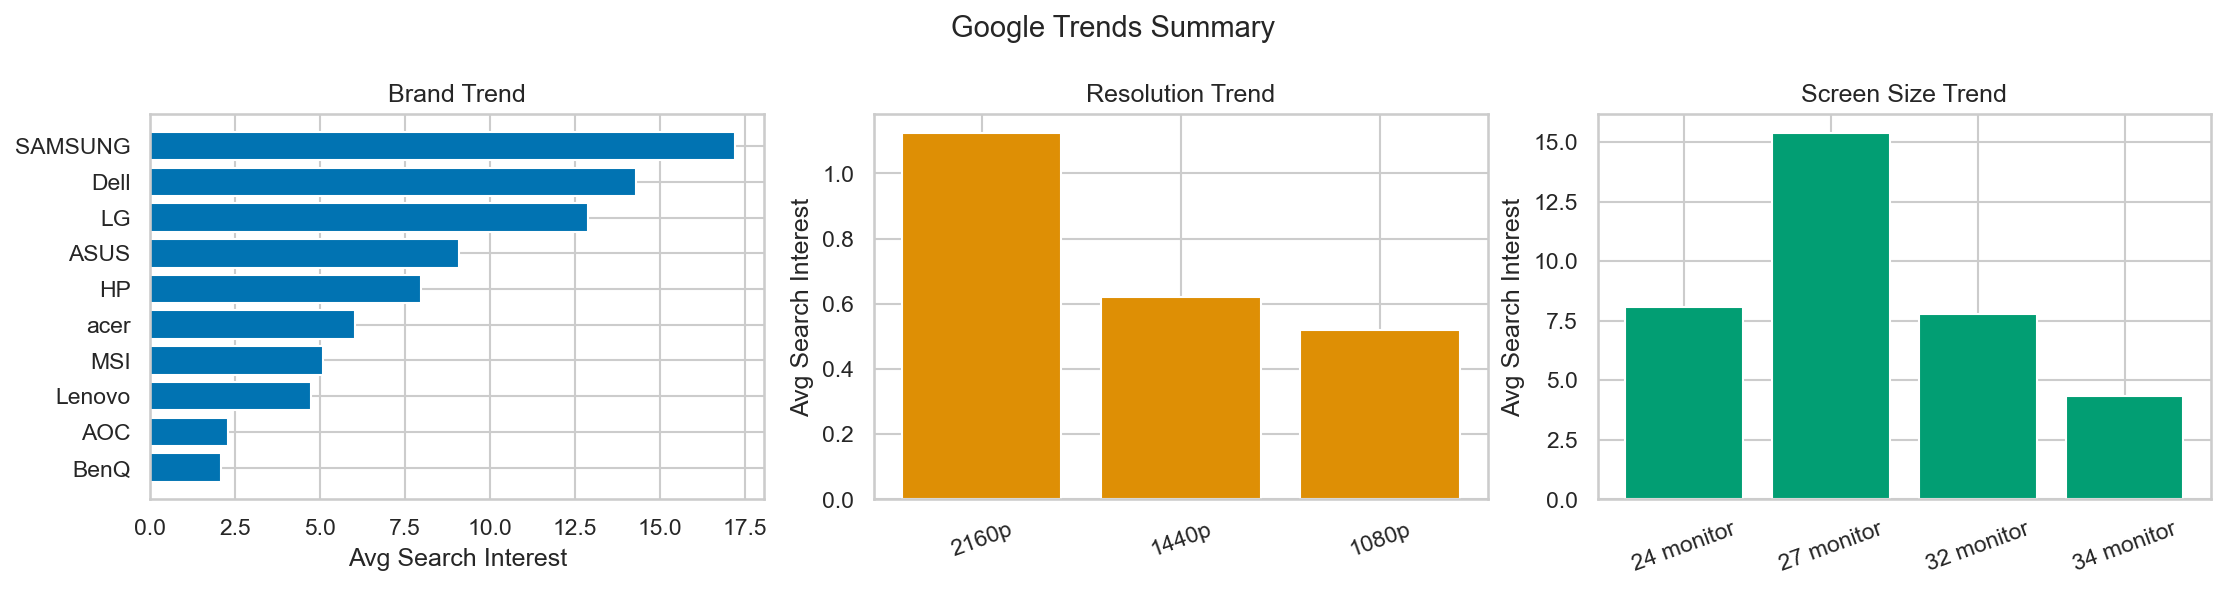

In [ ]:
df_brand, df_resolution, df_screen_size = process.fetch_all_trends(df_clean)
visualize.plot_trends_combined(df_brand, df_resolution, df_screen_size)

display(Image(config.TRENDS_SUMMARY))

In [6]:
df_brand.to_csv(config.TRENDS_BRAND_CSV, index=False)
print(f"Brand trends saved to {config.TRENDS_BRAND_CSV}")

df_resolution.to_csv(config.TRENDS_RES_CSV, index=False)
print(f"Resolution trends saved to {config.TRENDS_RES_CSV}")

df_screen_size.to_csv(config.TRENDS_SIZE_CSV, index=False)
print(f"Screen size trends saved to {config.TRENDS_SIZE_CSV}")

Brand trends saved to D:\SSI\DSCI510\finalproject_hanrui\results\trends_brand.csv
Resolution trends saved to D:\SSI\DSCI510\finalproject_hanrui\results\trends_resolution.csv
Screen size trends saved to D:\SSI\DSCI510\finalproject_hanrui\results\trends_screen_size.csv


## Step 3: Scrape Amazon Review Data
#### By simulating browser behavior to scrape the number of product reviews on Amazon, the scraping process may take nearly half an hour.
#### It is recommended to run the scraping step from the terminal using:

```python main.py --scrape```

#### This avoids conflicts between Playwright's Sync API and Jupyter's asyncio loop, and allows real-time output to be displayed in the terminal. Alternatively, the following command can be run directly in this notebook, but real-time output will not be visible during scraping:

```!{sys.executable} -u main.py --scrape```

e:\conda_env\envs\dsci510_env\python.exe
^C
[output] saved -> D:\SSI\DSCI510\finalproject_hanrui\results\review_distribution.png


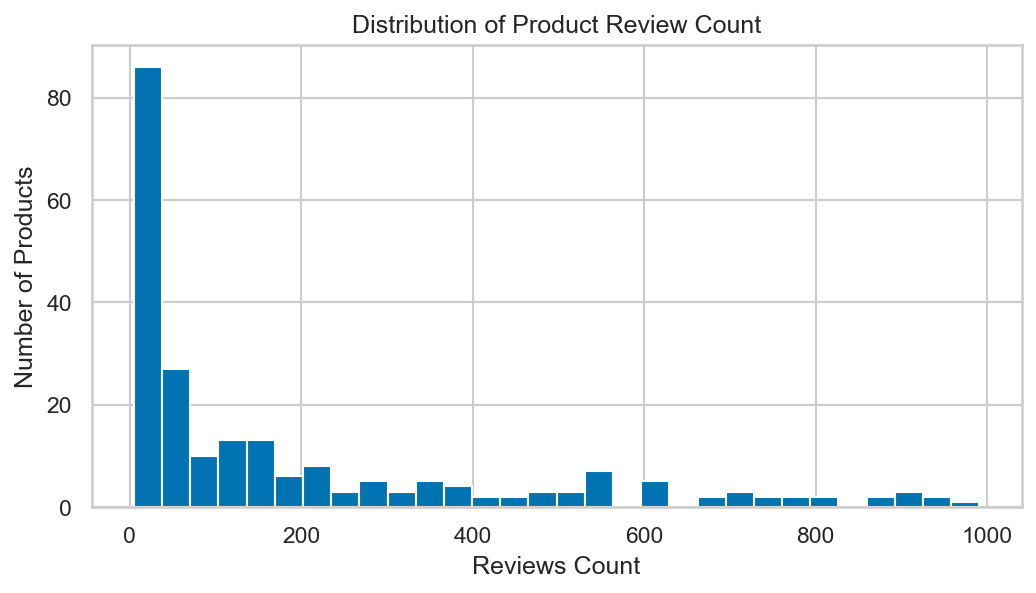

Successfully loaded 269 titles from D:\SSI\DSCI510\finalproject_hanrui\results\cleaned_products.csv.
Loaded 269 product titles for scraping.
Accessing Amazon homepage to get cookies.
Processed 10/269 items
{'input_title': 'Dell S3422DWG Curved Gaming Monitor - 34 Inch 1800R Curved Screen with 144Hz Refresh Rate, WQHD (3440 x 1440) Display, HDMI, DP to DP 1.4 Cable, AMD FreeSync - Black', 'matched_title': None, 'asin': 'B0F1H325FN', 'rating': 4.5, 'ratings_total': 382, 'status': 'success'}
Processed 20/269 items
{'input_title': 'Dell 24 Monitor - P2422H - Full HD 1080p, IPS Technology, ComfortView Plus Technology', 'matched_title': None, 'asin': 'B096T36G8L', 'rating': 4.6, 'ratings_total': 13, 'status': 'success'}
Processed 30/269 items
{'input_title': 'Acer SH242Y Ebmihx 23.8" FHD 1920x1080 Home Office Ultra-Thin IPS Computer Monitor AMD FreeSync 100Hz Zero Frame Height/Swivel/Tilt Adjustable Stand Built-in Speakers HDMI 1.4 & VGA Port', 'matched_title': None, 'asin': 'B09KG5FW1G', 'r

In [4]:
# print(sys.executable)
# !{sys.executable} -u main.py --scrape

df_reviews, _, _, _ = visualize.load_data()
visualize.plot_review_distribution(df_reviews)

display(Image(config.DISTRIBUTION_PLOT))

## Step 4: Analysis

In [5]:
df_model = load.load_all_data()
print(f"{len(df_model)} records ready for analysis")
df_model.head()

169 records ready for analysis


,Title,Brand,Screen Size,Resolution,Price,Rating,Reviews,Brand_Trend,Resolution_Trend,Size_Trend
0,"acer SB240Y G0bi 23.8"" IPS Full HD Ultra-Slim ...",acer,24.0,1080p,94.99,4.7,483.0,6.075472,0.526502,8.132075
1,"acer Nitro 31.5"" FHD 1920 x 1080 1500R Curved ...",acer,32.0,1080p,259.99,4.7,552.0,6.075472,0.526502,7.792453
2,"Acer SB272 EBI 27"" Full HD (1920 x 1080) IPS Z...",acer,27.0,1080p,99.99,4.6,18.0,6.075472,0.526502,15.490566
3,Sceptre 30-inch Curved Gaming Monitor 21:9 256...,Sceptre,30.0,1080p,199.97,4.5,216.0,1.549833,0.526502,NaN
4,"SAMSUNG 32"" UJ59 Series 4K UHD (3840x2160) Com...",SAMSUNG,32.0,2160p,279.99,4.2,34.0,17.264151,1.132543,7.792453


output saved to D:\SSI\DSCI510\finalproject_hanrui\results\correlation_matrix.png

Top correlations:
Resolution_Trend  Rating              0.436
Price             Resolution_Trend    0.413
                  Rating              0.292
                  Brand_Trend         0.265
Reviews           Brand_Trend         0.158
dtype: float64


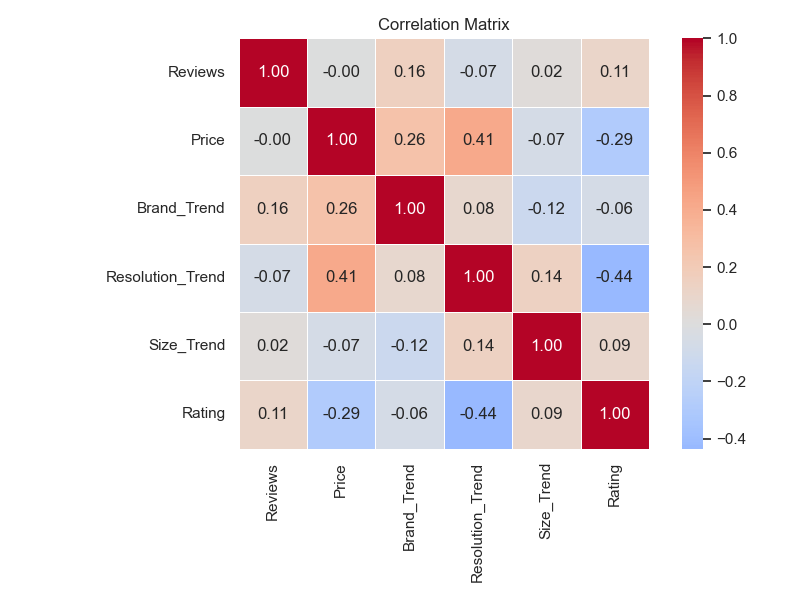

In [6]:
# Correlation Matrix
analysis.correlation_analysis(df_model)

display(Image(config.CORRELATION_MATRIX_PLOT))

                            OLS Regression Results                            
Dep. Variable:                Reviews   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     1.919
Date:                Tue, 05 May 2026   Prob (F-statistic):              0.128
Time:                        00:45:43   Log-Likelihood:                -1176.0
No. Observations:                 169   AIC:                             2360.
Df Residuals:                     165   BIC:                             2373.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          211.9045     68.000  

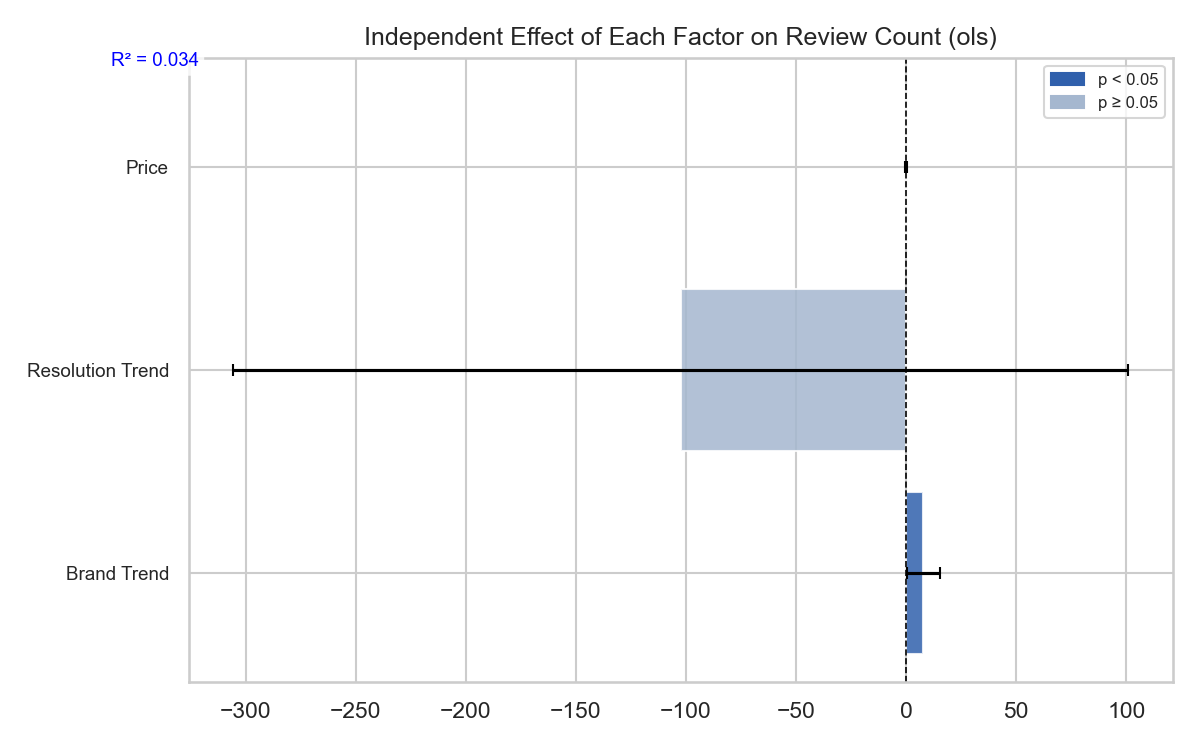

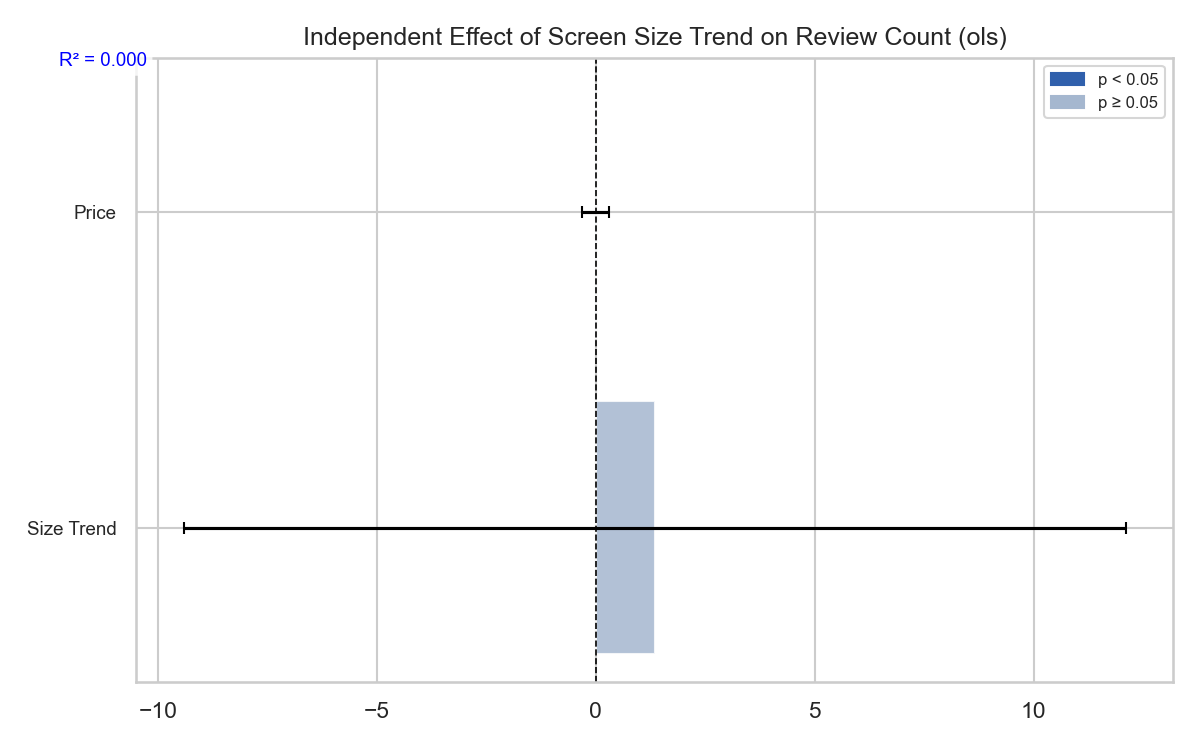

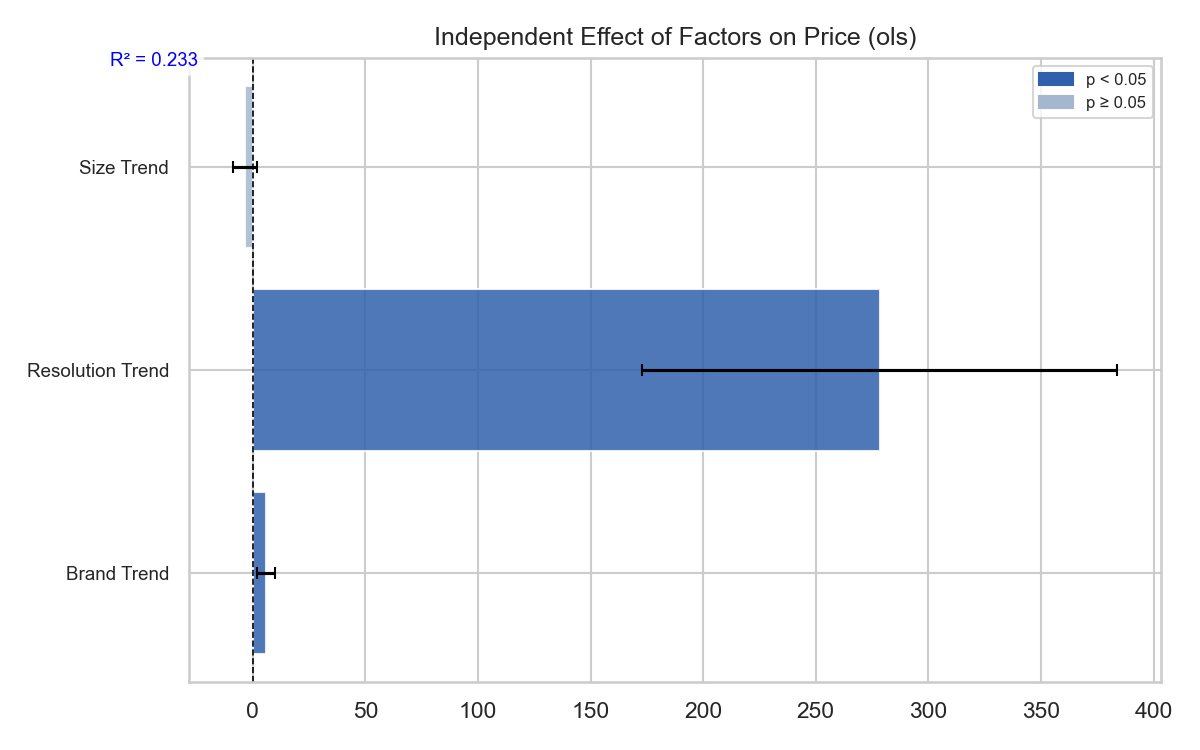

In [7]:
# Model
m1a, m1b, m2 = analysis.main_model(df_model)

display(Image(config.MODEL_1_PLOT))
display(Image(config.MODEL_2_PLOT))
display(Image(config.MODEL_3_PLOT))